In [2]:
import os
os.chdir('../../..')

In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import re

from rdkit import Chem
from rdkit.Chem import Draw
from collections import Counter
from scipy.stats import ks_2samp
from torch_geometric.datasets import QM9
from rdkit.Chem import Descriptors, rdMolDescriptors
from tqdm import tqdm

from src.datasets import QM9Dataset

In [4]:
qm9 = QM9Dataset(limit=None)
df = qm9.load(force_process=True)

2026-04-21 17:54:20.795 | INFO     | src.datasets:_process_raw_qm9:592 - Building full QM9 master parquet from raw Torch Geometric data.
Processing QM9: 100%|██████████| 130831/130831 [1:13:36<00:00, 29.63it/s]  
2026-04-21 19:07:57.880 | WARNING  | src.datasets:_process_raw_qm9:607 - Filtered out QM9 molecules during load because 3D embedding failed (dropped=8223, kept=122608).
2026-04-21 19:07:57.968 | SUCCESS  | src.datasets:_process_raw_qm9:623 - Saved full QM9 master parquet: rows=122608, path=data/QM9/dataset_cleaned.parquet
2026-04-21 19:07:58.235 | INFO     | src.datasets:_sample_qm9_df:692 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=122608.
2026-04-21 19:07:58.235 | INFO     | src.datasets:_add_requested_descriptors:129 - Applying requested QM9 descriptors to sampled dataframe (rows=122608).
2026-04-21 19:07:58.236 | INFO     | src.datasets:_add_requested_descriptors:154 - No new descriptor columns added (already present or none requested)

In [10]:
df['scaffold_smiles'].to_list()[-10:-1]

['C1[NH+]2C3C4C2C12C[NH+]4C32',
 'C1[NH+]2C3C4C5O[C@@]1(C53)C42',
 'C1C2[NH2+]C3C1C1C2[NH+]31',
 'C1C2[NH2+]C3C4C2C4[NH+]13',
 '[CH-]1C2OC3C1C1C2C31',
 'C1C2[NH2+]C3C4C2C4[NH+]13',
 '[CH-]1C2CC3C1C1C2[NH+]31',
 'C1C2[NH2+]C3C4C2C4[NH+]13',
 'C1OC[C@]23CC([NH2+]2)C13']

In [ ]:
frames = qm9.get_positions()

2026-03-18 08:32:53.423 | SUCCESS  | src.datasets:get_positions:885 - Saved 2000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 2000).


# Visualization of a few molecules
- Ensuring that SMILES works for generating unique identifiers for each molecule

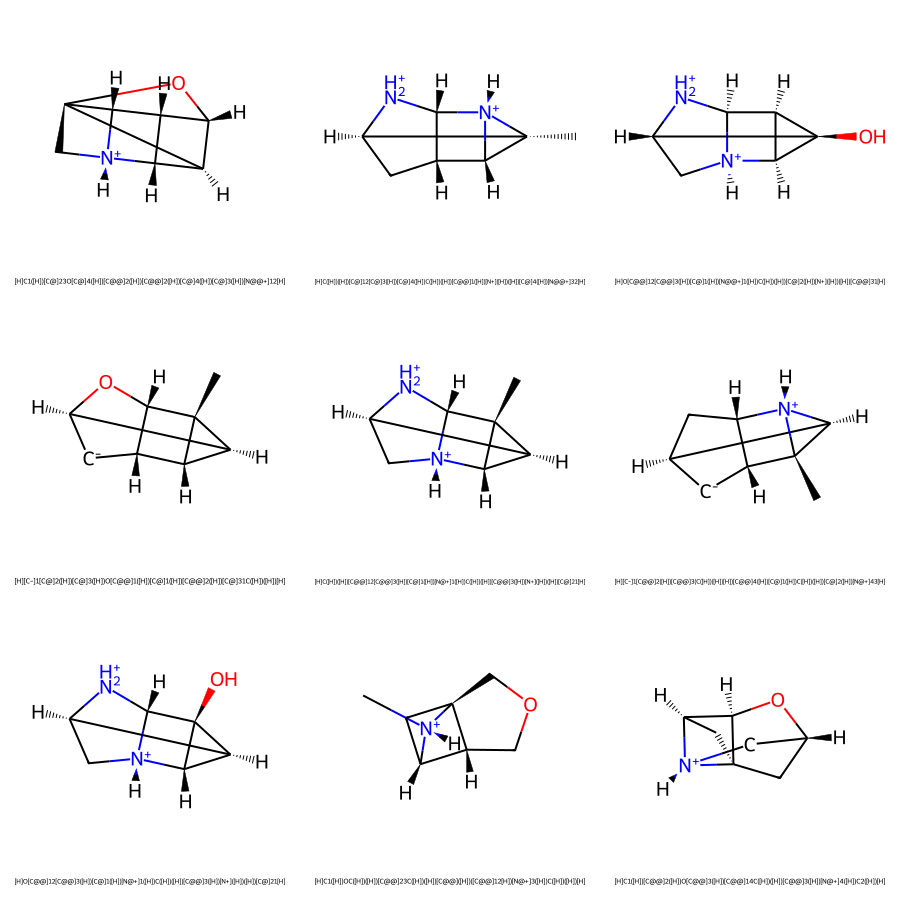

In [14]:
sample_smiles = df.tail(9)["canonical_smiles"].to_list()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img

# Figures for report

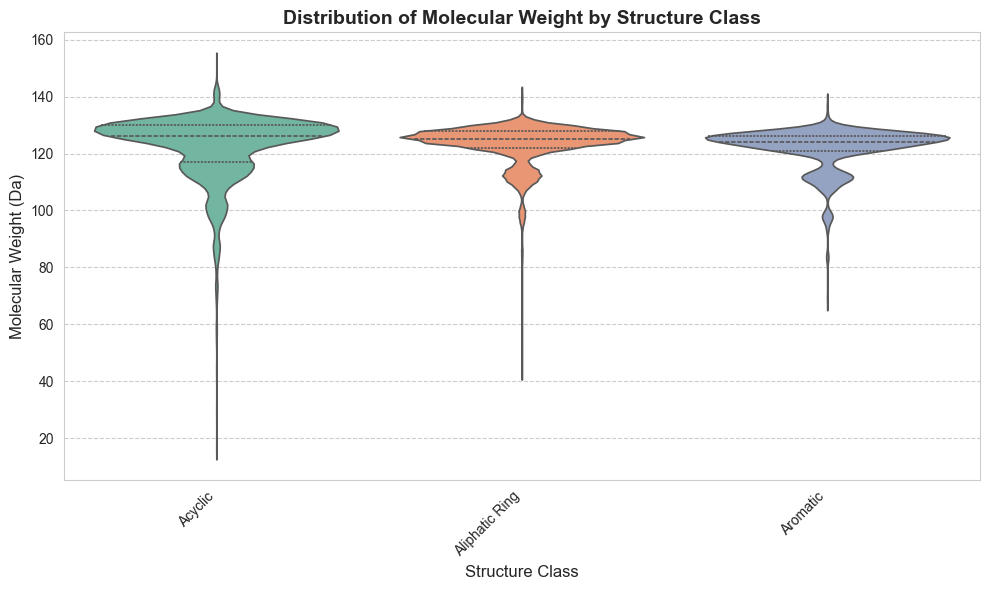

In [15]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df, 
    x='structure_class', 
    y='mol_weight', 
    palette='Set2', 
    hue='structure_class',
    inner='quartile'
)
plt.title('Distribution of Molecular Weight by Structure Class', fontsize=14, fontweight='bold')
plt.xlabel('Structure Class', fontsize=12)
plt.ylabel('Molecular Weight (Da)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/qm9/analysis/distribution_by_structure_class.png', dpi=300)
plt.show()

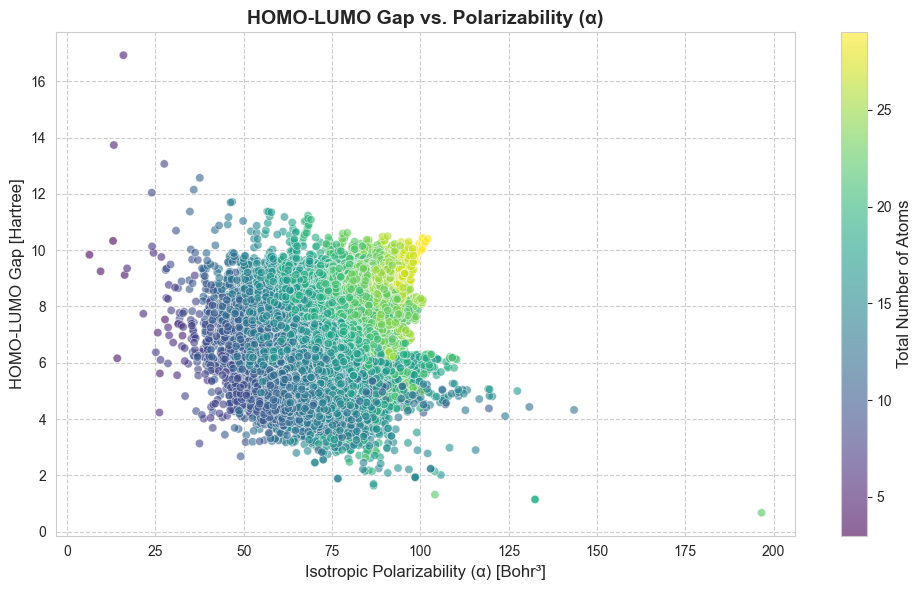

In [16]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['alpha'], 
    df['gap'], 
    c=df['num_atoms'], 
    cmap='viridis', 
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Total Number of Atoms', fontsize=12)

plt.title('HOMO-LUMO Gap vs. Polarizability (α)', fontsize=14, fontweight='bold')
plt.xlabel('Isotropic Polarizability (α) [Bohr³]', fontsize=12)
plt.ylabel('HOMO-LUMO Gap [Hartree]', fontsize=12)
plt.tight_layout()
plt.show()

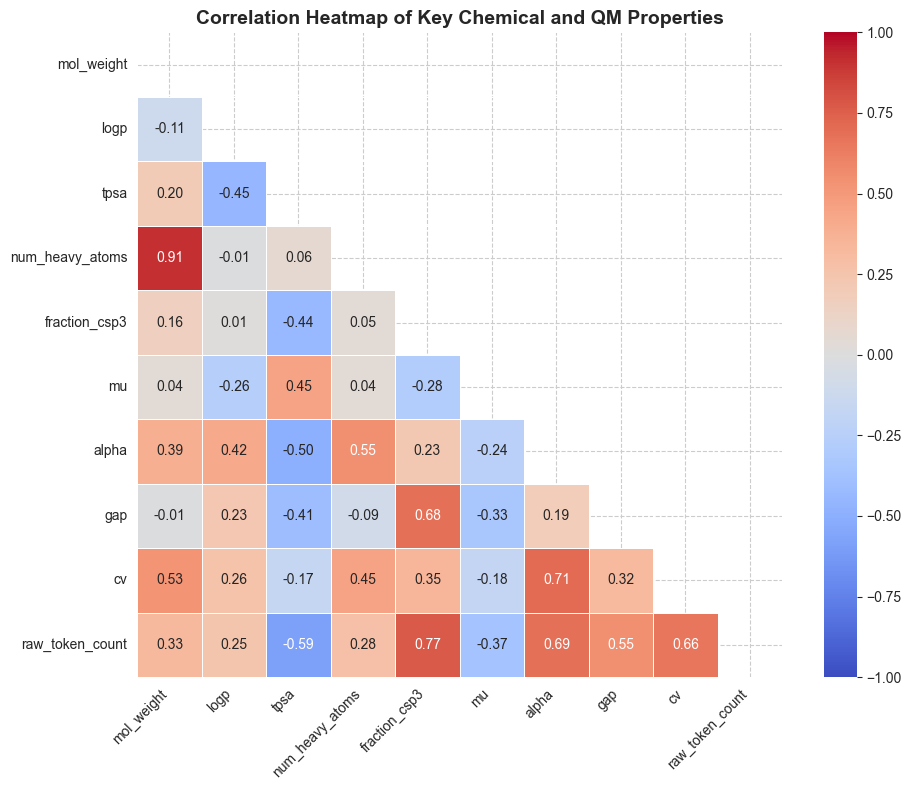

In [17]:
plt.figure(figsize=(10, 8))

# Select a mix of 2D cheminformatics features and 3D quantum features
features_of_interest = [
    'mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 
    'fraction_csp3', 'mu', 'alpha', 'gap', 'cv', 'raw_token_count'
]

# Calculate Spearman correlation (better for potentially non-linear chemical features)
corr = df[features_of_interest].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    xticklabels=features_of_interest,   # ← use names instead of 0,1,2…
    yticklabels=features_of_interest
)

plt.xticks(rotation=45, ha='right')      # if you want them tilted
plt.title('Correlation Heatmap of Key Chemical and QM Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

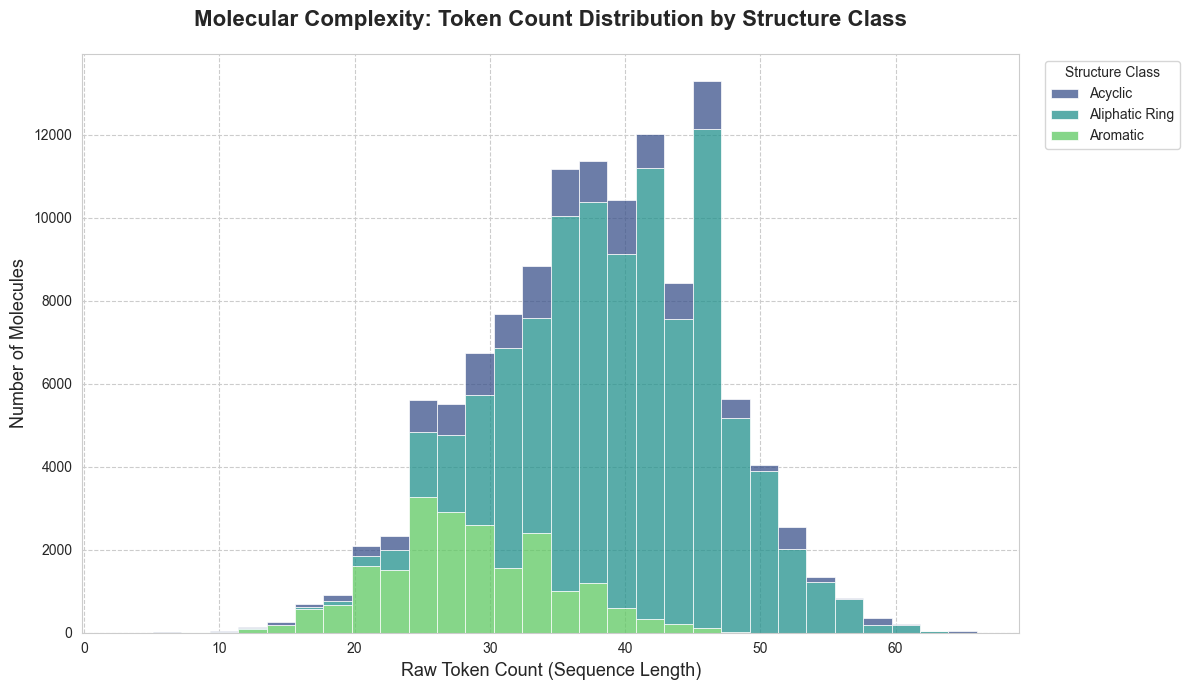

In [18]:
plt.figure(figsize=(12, 7))

# 1. Create the plot (Seaborn creates the legend automatically here)
ax = sns.histplot(
    data=df,
    x='raw_token_count',
    hue='structure_class',
    multiple='stack',
    palette='viridis',
    edgecolor='white',
    linewidth=0.5,
    bins=30
)

# 2. Access the auto-generated legend and move it
# This avoids the "No artists with labels found" warning
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Structure Class')

plt.title('Molecular Complexity: Token Count Distribution by Structure Class', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Raw Token Count (Sequence Length)', fontsize=13)
plt.ylabel('Number of Molecules', fontsize=13)

plt.tight_layout()
plt.savefig('figures/qm9/analysis/plot_token_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

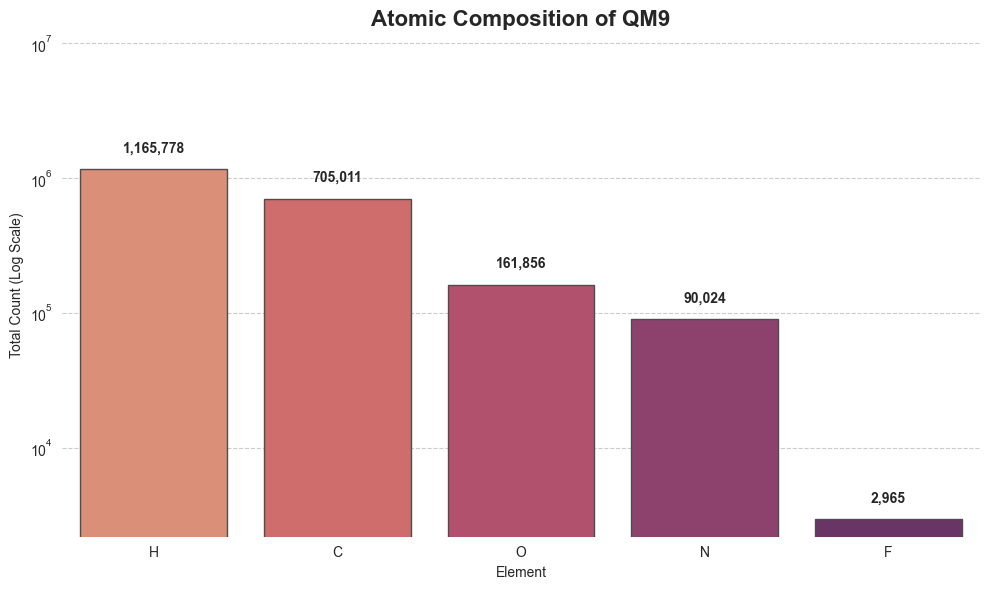

In [19]:
# 1. Processing - Using map(str) to avoid the AttributeError
all_smiles = "".join(map(str, df["canonical_smiles"]))

# Regex: Find Capital letters followed by optional lowercase (Elements)
# We filter out common SMILES syntax that isn't an element
tokens = re.findall(r'[A-Z][a-z]?', all_smiles)
valid_elements = {'H', 'C', 'N', 'O', 'F', 'S', 'Cl', 'P', 'Br', 'I'}
atom_counts = Counter([t for t in tokens if t in valid_elements])

comp_df = pd.DataFrame(atom_counts.items(), columns=['Element', 'Count'])
comp_df = comp_df.sort_values('Count', ascending=False)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.linestyle': '--'})

ax = sns.barplot(
    data=comp_df, 
    x='Element', 
    y='Count', 
    palette='flare',
    hue='Element',
    edgecolor='0.3'
)

ax.set_yscale("log")
plt.ylim(top=comp_df['Count'].max() * 10) # Added more headroom for labels

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Atomic Composition of QM9', fontsize=16, fontweight='bold')
plt.ylabel('Total Count (Log Scale)')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('figures/qm9/analysis/atomic_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Average weight of molecule
- Also average bond length

In [20]:
mol_weights = df['mol_weight']
print(np.average(mol_weights))

122.886353255905


In [21]:
mol_bond_lengths = df['avg_bond_length']
plotting = mol_bond_lengths.hist()
plotting

breakpoint,category,count
f64,cat,u32
1.022027,"""[0.980759, 1.022027]""",1
1.063295,"""(1.022027, 1.063295]""",1
1.104563,"""(1.063295, 1.104563]""",2
1.14583,"""(1.104563, 1.14583]""",3
1.187098,"""(1.14583, 1.187098]""",9
1.228366,"""(1.187098, 1.228366]""",4542
1.269634,"""(1.228366, 1.269634]""",74216
1.310902,"""(1.269634, 1.310902]""",43026
1.35217,"""(1.310902, 1.35217]""",803


# Plot of scaffolds

In [24]:
df['scaffold_smiles'].unique()

scaffold_smiles
str
"""C1=C[C@]23CC1OC2CO3"""
"""C1C2CC3(CC3)CC12"""
"""C1CC(c2nnon2)C1"""
"""C1=Cn2ncnc2CC1"""
"""C1CC2C[NH+]2CC2NC12"""
…
"""C1OCC2C3NC3C2O1"""
"""C1CC2C3CC(C3)C2C1"""
"""O=C(CC1CO1)C1CO1"""


# Similar Molecules for Grassmann stress test

In [ ]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# import pandas as pd

# df = df.to_pandas()
# # Assuming your dataframe is named 'df'
# mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

# # FIX: Use boolean indexing instead of .filter()
# sample_smiles = df[df["mol_id"].isin(mol_ids)]["canonical_smiles"].tolist()

# # Generate molecules
# mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

# # Create the grid image
# img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
# img

KeyError: 'mol_id'

In [ ]:
qm9 = QM9Dataset(limit=10)
df = qm9.load()
df

2026-03-31 14:15:50.266 | INFO     | src.datasets:load:397 - Loading QM9 from data/QM9/dataset_cleaned.parquet...
2026-03-31 14:15:50.375 | ERROR    | src.datasets:load:428 - Load failed (DataFrame size does not match expected value. Expected: 10, Actual: 250). Reprocessing...
2026-03-31 14:15:50.375 | INFO     | src.datasets:_process_raw_qm9:435 - Processing raw QM9 data (Limit: 10)...
2026-03-31 14:16:08.170 | INFO     | src.datasets:_process_raw_qm9:460 - Stratified sampling enabled. Selected 11 indices from QM9.
2026-03-31 14:16:10.716 | INFO     | src.features:compute_soap:160 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-31 14:16:10.978 | SUCCESS  | src.datasets:add_soap:644 - Added SOAP embeddings.
2026-03-31 14:16:10.979 | INFO     | src.features:compute_acsf:190 - Computing ACSF (rcut=6.0)...
2026-03-31 14:16:11.065 | SUCCESS  | src.datasets:add_acsf:655 - Added ACSF embeddings.
2026-03-31 14:16:11.066 | INFO     | src.features:compute_coulomb_matrix:224 - Computing C

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-31 14:16:16.293 | INFO     | src.features:compute_selfies_onehot:132 - Computing One-Hot Encodings...
2026-03-31 14:16:16.298 | INFO     | src.features:compute_chemprop_embeddings:273 - Computing Chemprop embeddings on mps...
2026-03-31 14:16:16.299 | WARNING  | src.features:compute_chemprop_embeddings:281 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-31 14:16:16.643 | SUCCESS  | src.datasets:add_all_descriptors:730 - Finished adding all requested descriptors.
2026-03-31 14:16:16.666 | SUCCESS  | src.datasets:_process_raw_qm9:570 - Saved processed dataset with 10 rows to data/QM9/dataset_cleaned.parquet


mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding,acsf_embedding,coulomb_matrix,morgan_fingerprint,selfies_transformer,selfies_onehot,chemprop_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64],list[f64],list[i8],list[f64],list[list[i64]],list[f64]
"""qm9_7062""","""C5H11NO2""","""[H]O[C@]([H])(C([H])([H])[H])[…","""[H]O[C@]([H])(C([H])([H])[H])[…","""[H][O][C@][Branch1][C][H][Bran…","""alcohol,amide""",19,"""Acyclic""",117,0,49,8,0,0,5,0.0,0.2,0.8,2,2,6,0,1,4,6,39,1.224874,0,1,0,0,1,0,0,0,0,0,3,4.113,69.160004,-6.661347,1.020427,7.681774,1107.417847,4.45298,-10945.325195,-10945.061523,-10945.036133,-10946.271484,34.424,-75.740097,-76.209198,-76.671875,-70.296051,2.92739,1.38077,1.16441,"[0.134036, 0.362934, … 0.0]","[4.651938, 1.134274, … 0.0]","[73.516695, 14.305351, … 0.0]","[0, 1, … 0]","[-0.128452, 0.474427, … -0.14335]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.007866, 0.210572, … 0.094938]"
"""qm9_10819""","""C8H12""","""[H]C#C[C@]1([H])C([H])([H])[C@…","""[H]C#C[C@]1([H])C([H])([H])[C@…","""[H][C][#C][C@][Branch1][C][H][…","""""",20,"""Aliphatic Ring""",108,2,0,8,1,0,2,0.25,0.0,0.75,0,0,6,2,0,6,8,42,1.249077,0,0,0,0,0,0,0,0,0,0,0,0.9084,82.139999,-6.879038,1.398665,8.277703,1318.819458,4.789258,-8485.402344,-8485.162109,-8485.135742,-8486.311523,33.063999,-83.139938,-83.670181,-84.158562,-77.404457,6.62484,0.96734,0.91013,"[0.1392, 0.377063, … 0.0]","[4.691402, 1.117681, … 0.0]","[36.858105, 16.667315, … 0.0]","[0, 0, … 0]","[-0.099389, 0.461142, … 0.063387]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.003079, 0.289734, … 0.091846]"
"""qm9_31856""","""C7H10O2""","""[H]C1=C(C([H])([H])[H])C([H])=…","""[H]c1oc(C([H])([H])OC([H])([H]…","""[H][C][O][C][Branch1][P][C][Br…","""ether""",19,"""Aromatic""",126,1,22,9,1,1,4,0.0,0.571429,0.428571,0,2,7,0,4,3,8,37,1.24486,0,0,0,0,0,0,0,0,1,0,2,1.1661,81.580002,-5.885823,0.427219,6.313041,1633.238525,4.304433,-11511.711914,-11511.455078,-11511.429688,-11512.667969,33.237,-81.315903,-81.791939,-82.254562,-75.789597,5.46348,0.77387,0.71909,"[0.122041, 0.327871, … 0.0]","[3.107056, 0.995582, … 0.0]","[73.516695, 17.714803, … 0.0]","[0, 0, … 0]","[-0.069562, 0.521498, … -0.130505]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.005963, 0.338384, … 0.152697]"
"""qm9_35044""","""C9H12""","""[H]C#CC([H])([H])[C@]12C([H])(…","""[H]C#CC([H])([H])[C@]12C([H])(…","""[H][C][#C][C][Branch1][C][H][B…","""""",21,"""Aliphatic Ring""",120,2,0,9,3,0,1,0.222222,0.0,0.777778,0,0,7,2,0,7,7,45,1.266363,0,0,0,0,0,0,0,0,0,0,0,0.6379,87.230003,-7.020537,1.518395,8.536211,1221.423584,4.998133,-9521.786133,-9521.563477,-9521.538086,-9522.677734,33.078999,-89.660759,-90.247086,-90.761169,-83.511208,3.50095,1.14405,1.07215,"[0.132987, 0.360613, … 0.0]","[4.697535, 1.008904, … 0.0]","[36.858105, 17.738091, … 0.5]","[1, 0, … 0]","[-0.088673, 0.247056, … -0.012411]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 0]]","[0.0, 0.368957, … 0.107452]"
"""qm9_51191""","""C6H7NO2""","""[H]C(=O)C#CC([H])([H])C([H])([…","""[H]C(=O)C#CC([H])([H])C([H])([…","""[H][C][=Branch1][C][=O][C][#C]…","""amide""",16,"""Acyclic""",125,0,46,9,0,0,2,0.333333,0.333333,0.333333,1,2,5,2,2,2,8,30,1.247132,0,0,0,0,1,0,0,0,0,0,3,5.0294,79.089996,-7.238229,-1.670779,5.56745,2175.593506,3.321694,-11915.53125,-11915.254883,-1

In [ ]:
df.columns

# Statified sampling

In [ ]:
qm9_head = QM9Dataset(sampling_strategy="head", limit=1000)
df_first = qm9_head.load(force_process=True)

qm9_random = QM9Dataset(sampling_strategy="random", limit=1000)
df_random = qm9_random.load(force_process=True)

qm9_strat = QM9Dataset(sampling_strategy="stratified", stratify_by=['num_atoms', 'gap'], limit=1000)
df_strat = qm9_strat.load(force_process=True)

2026-03-31 14:50:56.898 | INFO     | src.datasets:_process_raw_qm9:435 - Processing raw QM9 data (Limit: 1000)...
2026-03-31 14:50:59.659 | INFO     | src.features:compute_soap:160 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-31 14:51:02.403 | SUCCESS  | src.datasets:add_soap:644 - Added SOAP embeddings.
2026-03-31 14:51:02.404 | INFO     | src.features:compute_acsf:190 - Computing ACSF (rcut=6.0)...
2026-03-31 14:51:04.580 | SUCCESS  | src.datasets:add_acsf:655 - Added ACSF embeddings.
2026-03-31 14:51:04.581 | INFO     | src.features:compute_coulomb_matrix:224 - Computing Coulomb matrices (n_atoms_max=None, permutation=sorted_l2)...
2026-03-31 14:51:06.710 | SUCCESS  | src.datasets:add_coulomb_matrix:672 - Added Coulomb matrix descriptors.
2026-03-31 14:51:06.715 | WARNING  | src.datasets:_process_raw_qm9:499 - Invalid molecules (SOAP+ACSF+Coulomb failure): ['qm9_700']
2026-03-31 14:51:06.718 | INFO     | src.datasets:_process_raw_qm9:505 - Valid molecules (SOAP+ACSF+Coulom

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-31 14:51:17.022 | INFO     | src.features:compute_selfies_onehot:132 - Computing One-Hot Encodings...
2026-03-31 14:51:17.273 | INFO     | src.features:compute_chemprop_embeddings:273 - Computing Chemprop embeddings on mps...
2026-03-31 14:51:17.273 | WARNING  | src.features:compute_chemprop_embeddings:281 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-31 14:51:18.092 | SUCCESS  | src.datasets:add_all_descriptors:730 - Finished adding all requested descriptors.
2026-03-31 14:51:18.294 | SUCCESS  | src.datasets:_process_raw_qm9:570 - Saved processed dataset with 1000 rows to data/QM9/dataset_cleaned.parquet
2026-03-31 14:51:18.325 | INFO     | src.datasets:_process_raw_qm9:435 - Processing raw QM9 data (Limit: 1000)...
2026-03-31 14:51:18.869 | INFO     | src.datasets:_process_raw_qm9:465 - Random sampling enabled. Selected 1100 indices from QM9.
2026-03-31 14:51:47.050 | INFO     | src.features:compute_soap:160 - Computing SOAP (rcut=6.0, nmax=8, lmax=

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-31 14:52:20.377 | INFO     | src.features:compute_selfies_onehot:132 - Computing One-Hot Encodings...
2026-03-31 14:52:20.711 | INFO     | src.features:compute_chemprop_embeddings:273 - Computing Chemprop embeddings on mps...
2026-03-31 14:52:20.711 | WARNING  | src.features:compute_chemprop_embeddings:281 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-31 14:52:21.706 | SUCCESS  | src.datasets:add_all_descriptors:730 - Finished adding all requested descriptors.
2026-03-31 14:52:21.899 | SUCCESS  | src.datasets:_process_raw_qm9:570 - Saved processed dataset with 1000 rows to data/QM9/dataset_cleaned.parquet
2026-03-31 14:52:22.277 | INFO     | src.datasets:_process_raw_qm9:435 - Processing raw QM9 data (Limit: 1000)...
2026-03-31 14:52:30.755 | INFO     | src.datasets:_process_raw_qm9:460 - Stratified sampling enabled. Selected 1100 indices from QM9.
2026-03-31 14:52:53.913 | INFO     | src.features:compute_soap:160 - Computing SOAP (rcut=6.0, nmax=8, l

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-31 14:53:29.034 | INFO     | src.features:compute_selfies_onehot:132 - Computing One-Hot Encodings...
2026-03-31 14:53:30.125 | INFO     | src.features:compute_chemprop_embeddings:273 - Computing Chemprop embeddings on mps...
2026-03-31 14:53:30.126 | WARNING  | src.features:compute_chemprop_embeddings:281 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-31 14:53:30.910 | SUCCESS  | src.datasets:add_all_descriptors:730 - Finished adding all requested descriptors.
2026-03-31 14:53:31.175 | SUCCESS  | src.datasets:_process_raw_qm9:570 - Saved processed dataset with 1000 rows to data/QM9/dataset_cleaned.parquet


Extracting full QM9 population targets for validation...

--- Stratified Sample vs. Population ---
KS Statistic: 0.0303 (Closer to 0 is better)
P-value:      0.3142 (Larger than 0.05 is good)

--- Random Sample vs. Population ---
KS Statistic: 0.0302
P-value:      0.3201

--- Head Sample vs. Population ---
KS Statistic: 0.1267
P-value:      0.0000


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_12823/3087955168.py:34: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(pop_gaps, label="Original QM9 Population", color="gray", shade=True, bw_adjust=0.5)


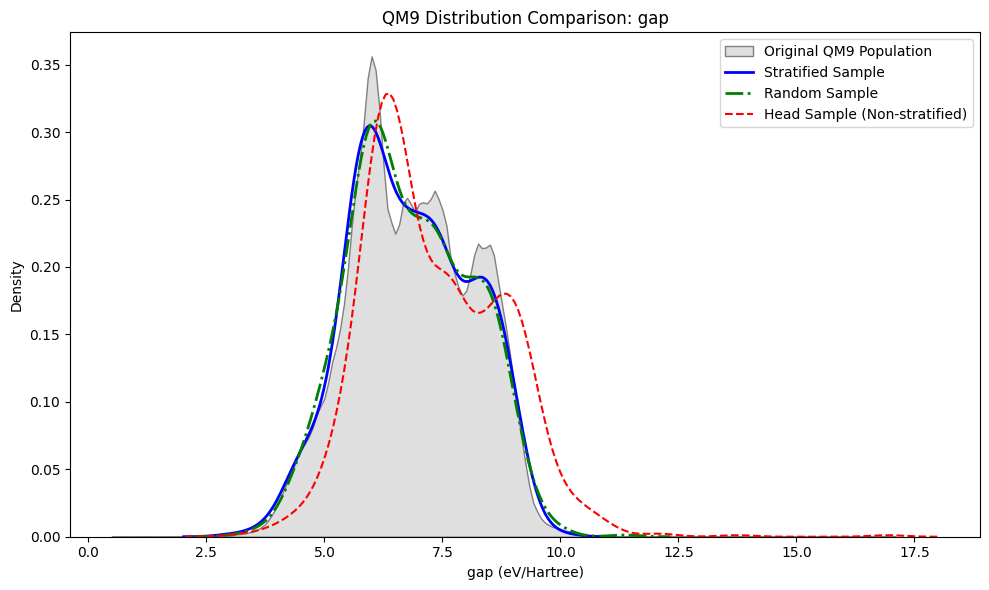

In [ ]:
# 2. Lightning-fast Population Extraction (Bypasses SOAP/ACSF processing)
print("Extracting full QM9 population targets for validation...")
raw_dataset = QM9(root="data/QM9")
gap_idx = QM9Dataset.QM9_TARGETS.index("gap")

# Extract the gap values for all 130,000+ molecules directly
pop_gaps = np.array([data.y[0, gap_idx].item() for data in raw_dataset])

# 3. Clean nulls
strat_gaps = df_strat["gap"].drop_nulls().to_numpy()
head_gaps = df_first["gap"].drop_nulls().to_numpy()
rand_gaps = df_random["gap"].drop_nulls().to_numpy() # Added df_random

# 4. Kolmogorov-Smirnov Tests
print("\n--- Stratified Sample vs. Population ---")
stat_strat, p_strat = ks_2samp(pop_gaps, strat_gaps)
print(f"KS Statistic: {stat_strat:.4f} (Closer to 0 is better)")
print(f"P-value:      {p_strat:.4f} (Larger than 0.05 is good)")

print("\n--- Random Sample vs. Population ---") # Added df_random
stat_rand, p_rand = ks_2samp(pop_gaps, rand_gaps)
print(f"KS Statistic: {stat_rand:.4f}")
print(f"P-value:      {p_rand:.4f}")

print("\n--- Head Sample vs. Population ---")
stat_head, p_head = ks_2samp(pop_gaps, head_gaps)
print(f"KS Statistic: {stat_head:.4f}")
print(f"P-value:      {p_head:.4f}")

# 5. Visual Validation
plt.figure(figsize=(10, 6))

# Plot Population
sns.kdeplot(pop_gaps, label="Original QM9 Population", color="gray", shade=True, bw_adjust=0.5)

# Plot Stratified
sns.kdeplot(strat_gaps, label="Stratified Sample", color="blue", linewidth=2)

# Plot Random
sns.kdeplot(rand_gaps, label="Random Sample", color="green", linestyle="-.", linewidth=2)

# Plot Head Sample
sns.kdeplot(head_gaps, label="Head Sample (Non-stratified)", color="red", linestyle="--")

plt.title("QM9 Distribution Comparison: gap")
plt.xlabel("gap (eV/Hartree)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.savefig('figures/qm9/sampling/stat_sampling_validation.png', dpi=300)

plt.show()